## 数据采集

In [ ]:
import numpy as np
# os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # or any {'0', '1', '2'}

def sin_dataset():
    np.random.seed(0)
    train_data = np.linspace(-np.pi, np.pi, 1000)
    train_labels = np.sin(train_data)
    # 1000 * 1
    train_data = np.expand_dims(train_data, axis=1)
    train_labels = np.expand_dims(train_labels, axis=1)

    return (train_data, train_labels)


## 函数定义

In [220]:
import numpy as np

class Matmul:
    def __init__(self):
        self.mem = {}
        
    def forward(self, x, W):
        h = np.matmul(x, W)
        self.mem={'x': x, 'W':W}
        return h
    
    def backward(self, grad_y):
        '''
        x: shape(N, d)
        w: shape(d, d')
        grad_y: shape(N, d')
        '''
        x = self.mem['x']
        W = self.mem['W']
        
        ####################
        '''计算矩阵乘法的对应的梯度'''
        ####################
        grad_x = np.matmul(grad_y, W.T)
        grad_W = np.matmul(x.T, grad_y)
        return grad_x, grad_W


class Relu:
    def __init__(self):
        self.mem = {}
        
    def forward(self, x):
        self.mem['x']=x
        return np.where(x > 0, x, np.zeros_like(x))
    
    def backward(self, grad_y):
        '''
        grad_y: same shape as x
        '''
        ####################
        '''计算relu 激活函数对应的梯度'''
        ####################
        x = self.mem['x']
        grad_x = np.where(x > 0, grad_y, np.zeros_like(grad_y))
        return grad_x
    


# class Softmax:
#     '''
#     softmax over last dimention
#     '''
#     def __init__(self):
#         self.epsilon = 1e-12
#         self.mem = {}
        
#     def forward(self, x):
#         '''
#         x: shape(N, c)
#         '''
#         x_exp = np.exp(x)
#         partition = np.sum(x_exp, axis=1, keepdims=True)
#         out = x_exp/(partition+self.epsilon)
        
#         self.mem['out'] = out
#         self.mem['x_exp'] = x_exp
#         return out
    
#     def backward(self, grad_y):
#         '''
#         grad_y: same shape as x
#         '''
#         s = self.mem['out']
#         sisj = np.matmul(np.expand_dims(s,axis=2), np.expand_dims(s, axis=1)) # (N, c, c)
#         g_y_exp = np.expand_dims(grad_y, axis=1)
#         tmp = np.matmul(g_y_exp, sisj) #(N, 1, c)
#         tmp = np.squeeze(tmp, axis=1)
#         tmp = -tmp+grad_y*s 
#         return tmp
    
# class Log:
#     '''
#     softmax over last dimention
#     '''
#     def __init__(self):
#         self.epsilon = 1e-12
#         self.mem = {}
        
#     def forward(self, x):
#         '''
#         x: shape(N, c)
#         '''
#         out = np.log(x+self.epsilon)
        
#         self.mem['x'] = x
#         return out
    
#     def backward(self, grad_y):
#         '''
#         grad_y: same shape as x
#         '''
#         x = self.mem['x']
        
#         return 1./(x+1e-12) * grad_y
    


## 模型描述

In [ ]:
class myModel:
    def __init__(self):
        
        self.W1 = np.random.randn(2, 500) * np.sqrt(2 / (2 + 500))  # He 初始化
        self.W2 = np.random.randn(500, 1) * np.sqrt(2 / (500 + 1))  # He 初始化
        
        self.mul_h1 = Matmul()
        self.mul_h2 = Matmul()
        self.relu1 = Relu()
        
        
    def forward(self, x):
        bias = np.ones(shape=[x.shape[0], 1])
        # 加上偏置1列 1000 * 2
        x = np.concatenate([x, bias], axis=1)
        
        self.h1 = self.mul_h1.forward(x, self.W1)
        self.h1_relu1 = self.relu1.forward(self.h1)
        self.h2 = self.mul_h2.forward(self.h1_relu1, self.W2)
            
    def backward(self, label):
        self.out_grad = self.h2 - label
        self.h2_grad, self.W2_grad = self.mul_h2.backward(self.out_grad)
        self.h1_relu1_grad = self.relu1.backward(self.h2_grad)
        self.h1_grad, self.W1_grad = self.mul_h1.backward(self.h1_relu1_grad)
        
model = myModel()


## 计算 loss

In [222]:
def compute_loss(relu_prob , labels):
     return np.mean(np.square(relu_prob - labels))
    

def train_one_step(model, x, y):
    model.forward(x)
    model.backward(y)
    model.W1 -= 1e-4* model.W1_grad
    model.W2 -= 1e-4* model.W2_grad
    loss = compute_loss(model.h2, y)
    return loss

def test(model, x, y):
    model.forward(x)
    loss = compute_loss(model.h2, y)
    return loss

## 实际训练

In [223]:
train_data = sin_dataset()
train_label = train_data[1]

for epoch in range(3000):
    loss = train_one_step(model, train_data[0], train_label)
    if epoch % 50 == 0:
        print('epoch', epoch, ': loss', loss)

epoch 0 : loss 0.5649801554783651
epoch 50 : loss 0.10512115805471177
epoch 100 : loss 0.07050040204158842
epoch 150 : loss 0.04768381176912233
epoch 200 : loss 0.03272498997462713
epoch 250 : loss 0.023227627883100888
epoch 300 : loss 0.017167921397067486
epoch 350 : loss 0.013143960596076565
epoch 400 : loss 0.010339954055214704
epoch 450 : loss 0.008307957185529404
epoch 500 : loss 0.006791385030975851
epoch 550 : loss 0.005632838376773501
epoch 600 : loss 0.004730143352845004
epoch 650 : loss 0.004015039060246874
epoch 700 : loss 0.00344041255527642
epoch 750 : loss 0.0029729156219109164
epoch 800 : loss 0.0025881618663500766
epoch 850 : loss 0.0022683162376142267
epoch 900 : loss 0.002000063671218553
epoch 950 : loss 0.0017732774890970896
epoch 1000 : loss 0.0015801678034322647
epoch 1050 : loss 0.0014146916141103611
epoch 1100 : loss 0.0012720686903636453
epoch 1150 : loss 0.0011484814620281916
epoch 1200 : loss 0.0010408743976129636
epoch 1250 : loss 0.00094674395526876
epoch 13

## 拟合效果

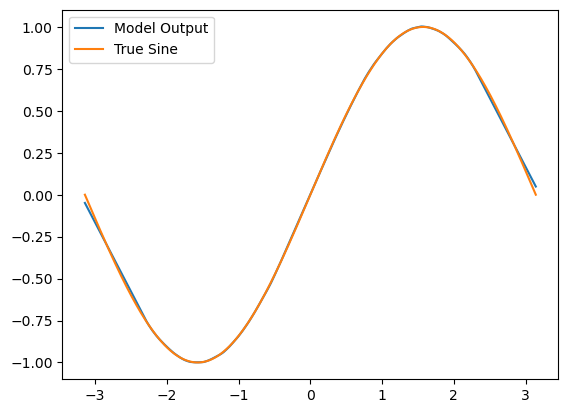

In [224]:
import matplotlib.pyplot as plt
x = np.linspace(-np.pi, np.pi, 1000)
x_expand = np.expand_dims(x, axis=1)
model.forward(x_expand)
plt.plot(x, model.h2, label='Model Output')
plt.plot(x, np.sin(x), label='True Sine')
plt.legend()
plt.show()